# **FRAMEWORK V7 - RESULTADOS**

In [ ]:
# Funciones modulares reutilizables para C16
from pathlib import Path
import sys

PROJECT_SRC = Path.cwd() / "src"
if PROJECT_SRC.exists() and str(PROJECT_SRC) not in sys.path:
    sys.path.insert(0, str(PROJECT_SRC))

from framework_v7.pipeline.interpretation import (
    compare_predictions_with_actuals,
    dimension_coverage,
    interpret_experiment_summary,
    load_interpretation_summary,
    metrics_from_comparison,
    summarize_interpretation_experiments,
)


## **M1. Validación de las predicciones**

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import requests

# --- Configuración y Rutas (Ajustar según sea necesario en el nuevo notebook) ---
EXPERIMENTO = "Exp04" # Asegúrate de que coincida con el experimento original

# Base URL para datasets y metadata (asumiendo que las rutas son las mismas)
BASE_URL = (
    "https://raw.githubusercontent.com/jriatiga/FRAMEWORK_V7/refs/heads/main/DATA/"
)

BASE_TRANSFORMACIONES = BASE_URL + "MACHINE_LEARNING/C13_MACHINE_LEARNING/Transformaciones/"

def obtener_url_dataset(exp):
    # 1. Intentar con la versión específica
    url_especifica = f"{BASE_TRANSFORMACIONES}{exp}/dataset_machine_learning_transformado.parquet"

    response = requests.head(url_especifica)
    if response.status_code == 200:
        return url_especifica

    # 2. Si tiene versión (ej. -V3), extraer la ruta principal (ej. Exp01)
    if "-" in exp:
        exp_base = exp.split("-")[0]
        url_base = f"{BASE_TRANSFORMACIONES}{exp_base}/dataset_machine_learning_transformado.parquet"

        response_base = requests.head(url_base)
        if response_base.status_code == 200:
            print(f"No se encontró el dataset para {exp}, usando la ruta principal: {exp_base}")
            return url_base

    return url_especifica

URL_DATASET = obtener_url_dataset(EXPERIMENTO)
CARPETA_PREDICCIONES = f"predicciones/{EXPERIMENTO}"

print("Librerías importadas y rutas configuradas.")
print("URL del Dataset:", URL_DATASET)

Librerías importadas y rutas configuradas.
URL del Dataset: https://raw.githubusercontent.com/jriatiga/FRAMEWORK_V7/refs/heads/main/DATA/MACHINE_LEARNING/C13_MACHINE_LEARNING/Transformaciones/Exp04/dataset_machine_learning_transformado.parquet


In [2]:
# Cargar metadata de la predicción para obtener 'VENTANA' y 'VARIABLE_OBJETIVO'
# Primero descargamos el archivo si no está disponible localmente
metadata_prediccion_url = f'{BASE_URL}EVALUACIONES/{EXPERIMENTO}/metadata_prediccion.csv'

# Nota: Si el archivo ya fue exportado al entorno de Colab en la ejecución anterior,
# puedes cargarlo directamente desde 'CARPETA_PREDICCIONES/metadata_prediccion.csv'
# De lo contrario, se descarga de la URL de GitHub.

try:
    metadata_prediccion = pd.read_csv(f'{CARPETA_PREDICCIONES}/metadata_prediccion.csv')
    print(f"Metadata cargada desde {CARPETA_PREDICCIONES}/metadata_prediccion.csv")
except FileNotFoundError:
    print(f"Archivo local no encontrado, descargando metadata de: {metadata_prediccion_url}")
    # Remove the old metadata_prediccion.csv to avoid using an empty/corrupted file
    !rm -f metadata_prediccion.csv
    !wget -q -O metadata_prediccion.csv {metadata_prediccion_url}
    metadata_prediccion = pd.read_csv('metadata_prediccion.csv')

VENTANA = int(metadata_prediccion.loc[metadata_prediccion['Parametro'] == 'Ventana', 'Valor'].iloc[0])
VARIABLE_OBJETIVO = metadata_prediccion.loc[metadata_prediccion['Parametro'] == 'Variable Objetivo', 'Valor'].iloc[0]

print(f"VENTANA recuperada: {VENTANA}")
print(f"VARIABLE_OBJETIVO recuperada: {VARIABLE_OBJETIVO}")
display(metadata_prediccion)

Archivo local no encontrado, descargando metadata de: https://raw.githubusercontent.com/jriatiga/FRAMEWORK_V7/refs/heads/main/DATA/EVALUACIONES/Exp04/metadata_prediccion.csv
VENTANA recuperada: 12
VARIABLE_OBJETIVO recuperada: VolumenUtilDiarioMasa


,Parametro,Valor
0,Experimento,Exp04
1,Dominio,Gestión Hídrica
2,Variable Objetivo,VolumenUtilDiarioMasa
3,Modelo,modelo_Exp04_VolumenUtilDiarioMasa.keras
4,Metodo Transformacion,RobustScaler
5,Ventana,12
6,Variables Predictoras,8
7,Registros Procesados,528
8,Predicciones Generadas,517
9,Fecha Ejecucion,2026-07-31 02:42


In [3]:
# Cargar el dataset original para obtener los valores reales de 'irca'
dataset_prediccion = pd.read_parquet(URL_DATASET)

# Cargar las predicciones generadas
URL_PREDICCIONES = f'{BASE_URL}EVALUACIONES/{EXPERIMENTO}/predicciones.csv'

try:
    resultados = pd.read_csv(f'{CARPETA_PREDICCIONES}/predicciones.csv')
    print(f"Predicciones cargadas desde {CARPETA_PREDICCIONES}/predicciones.csv")
except FileNotFoundError:
    print(f"Archivo de predicciones no encontrado localmente, descargando de: {URL_PREDICCIONES}")
    # Crear la carpeta si no existe
    !mkdir -p {CARPETA_PREDICCIONES}
    # Descargar el archivo a la carpeta especificada
    !wget -q -O {CARPETA_PREDICCIONES}/predicciones.csv {URL_PREDICCIONES}
    resultados = pd.read_csv(f'{CARPETA_PREDICCIONES}/predicciones.csv')


print("Dataset original y predicciones cargadas.")
display(dataset_prediccion.head())
display(resultados.head())

Predicciones cargadas desde predicciones/Exp04/predicciones.csv
Dataset original y predicciones cargadas.


,Precipitacion_mm,ONI,Radiacion_Solar,Humedad_Relativa,Temp_Min_C,Mes,Velocidad_Viento,irca,VolumenUtilDiarioMasa
0,-0.594799,0.570842,0.628362,-1.191977,-0.710044,-1.000000,0.944444,0.0,0
1,-0.685579,0.480493,0.325183,-1.055874,0.621605,-0.818182,0.305556,0.0,0
2,-0.112530,0.480493,0.066015,-0.848138,0.571068,-0.636364,0.166667,0.0,0
3,0.059574,0.685832,0.031785,-0.842407,0.391661,-0.454545,0.111111,0.0,0
4,-0.486998,0.858316,-0.242054,-0.949857,0.247631,-0.272727,0.305556,0.0,0


,Registro,Prediccion
0,12,-0.013860
1,13,-0.012214
2,14,-0.033293
3,15,-0.037542
4,16,-0.033594


In [4]:

valores_reales = dataset_prediccion[VARIABLE_OBJETIVO].iloc[VENTANA - 1 : VENTANA - 1 + len(resultados)].reset_index(drop=True)

# Crear un DataFrame para la visualización
df_comparacion = pd.DataFrame({
    'Registro': resultados['Registro'],
    'Prediccion': resultados['Prediccion'],
    'Real': valores_reales
})

print("\n"+"="*90)
print("COMPARACIÓN DE PREDICCIONES VS. VALORES REALES - Primeras filas")
print("="*90+"\n")
display(df_comparacion.head())

print("\n"+"="*90)
print("COMPARACIÓN DE PREDICCIONES VS. VALORES REALES - Últimas filas")
print("="*90+"\n")
display(df_comparacion.tail())


COMPARACIÓN DE PREDICCIONES VS. VALORES REALES - Primeras filas



,Registro,Prediccion,Real
0,12,-0.013860,0
1,13,-0.012214,0
2,14,-0.033293,0
3,15,-0.037542,0
4,16,-0.033594,0



COMPARACIÓN DE PREDICCIONES VS. VALORES REALES - Últimas filas



,Registro,Prediccion,Real
512,524,0.604704,1
513,525,0.560980,1
514,526,0.525629,1
515,527,0.376771,1
516,528,-0.019321,1


Gráfico guardado como imagen en: predicciones/Exp04/comparacion_predicciones.png


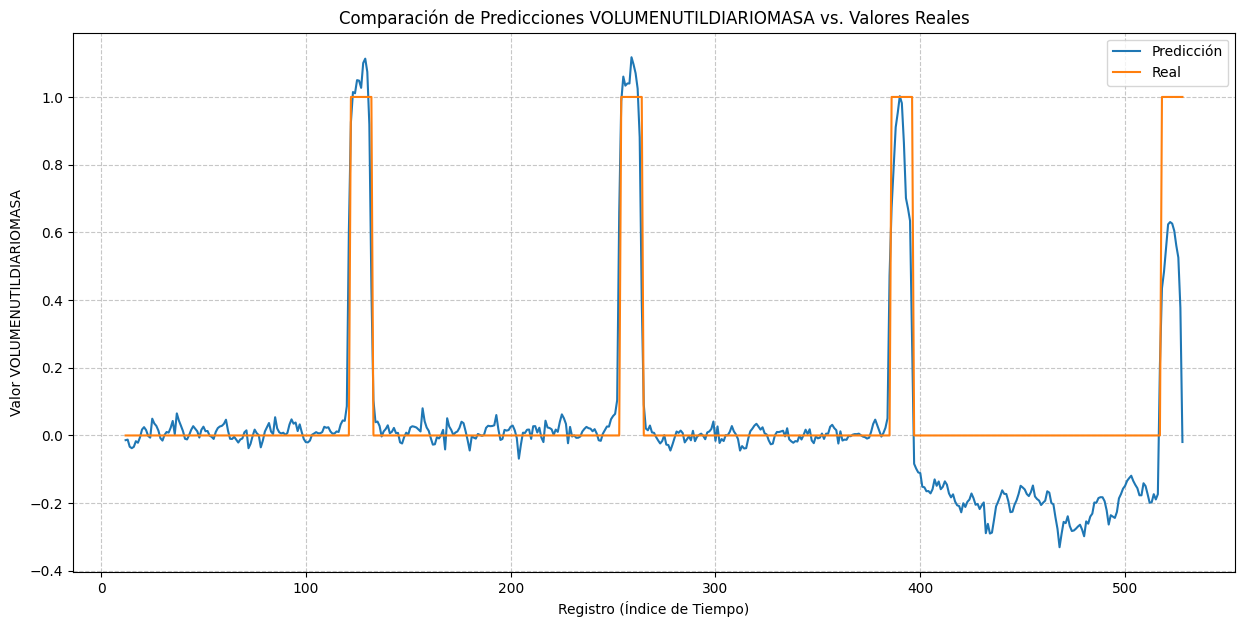

In [5]:
# Graficar Predicciones vs. Valores Reales
plt.figure(figsize=(15, 7))
sns.lineplot(x='Registro', y='Prediccion', data=df_comparacion, label='Predicción')
sns.lineplot(x='Registro', y='Real', data=df_comparacion, label='Real')
plt.title(f'Comparación de Predicciones {VARIABLE_OBJETIVO.upper()} vs. Valores Reales')
plt.xlabel('Registro (Índice de Tiempo)')
plt.ylabel(f'Valor {VARIABLE_OBJETIVO.upper()}')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)

# Ruta para guardar la imagen
output_image_path = f'{CARPETA_PREDICCIONES}/comparacion_predicciones.png'

# Guardar la figura antes de mostrarla
plt.savefig(output_image_path, dpi=300, bbox_inches='tight')
print(f"Gráfico guardado como imagen en: {output_image_path}")

plt.show()

## **M2. Interpretación del Comportamiento Temporal de las Predicciones**

In [6]:
# ==========================================================================================
# CARGA DE SECUENCIAS TEMPORALES Y REGISTRO DE PREPARACION
# ==========================================================================================
import numpy as np
import pandas as pd
import requests

# Base para transformaciones
BASE_TRANSFORMACIONES = (
    "https://raw.githubusercontent.com/jriatiga/FRAMEWORK_V7/refs/heads/main/"
    "DATA/MACHINE_LEARNING/C13_MACHINE_LEARNING/Transformaciones/"
)

def obtener_base_url_exp(exp):
    # 1. Intentar con la ruta del experimento específico
    url_prueba = f"{BASE_TRANSFORMACIONES}{exp}/metadata_secuencias.csv"
    response = requests.head(url_prueba)
    if response.status_code == 200:
        return f"{BASE_TRANSFORMACIONES}{exp}/"

    # 2. Si tiene versión (ej. -V3), extraer la ruta principal (ej. Exp01)
    if "-" in exp:
        exp_base = exp.split("-")[0]
        url_prueba_base = f"{BASE_TRANSFORMACIONES}{exp_base}/metadata_secuencias.csv"
        response_base = requests.head(url_prueba_base)
        if response_base.status_code == 200:
            print(f"No se encontró la ruta para {exp}, usando la ruta principal: {exp_base}")
            return f"{BASE_TRANSFORMACIONES}{exp_base}/"

    return f"{BASE_TRANSFORMACIONES}{exp}/"

# Base URL con fallback automático
base_url = obtener_base_url_exp(EXPERIMENTO)

# URLs completas de los archivos
x_sequence_url = base_url + "secuencias_X.npy"
y_sequence_url = base_url + "secuencias_y.npy"
metadata_sequence_url = base_url + "metadata_secuencias.csv"

# Nombres de archivo locales
x_sequence_filename = "secuencias_X.npy"
y_sequence_filename = "secuencias_y.npy"
metadata_sequence_filename = "metadata_secuencias.csv"

# Descargar los archivos
!wget -O {x_sequence_filename} {x_sequence_url}
!wget -O {y_sequence_filename} {y_sequence_url}
!wget -O {metadata_sequence_filename} {metadata_sequence_url}

secuencias_X = np.load(x_sequence_filename)
secuencias_y = np.load(y_sequence_filename)
metadata = pd.read_csv(metadata_sequence_filename)

print()
print("="*90)
print("SECUENCIAS CARGADAS")
print("="*90)
print()
print(f"Secuencias X : {secuencias_X.shape}")
print(f"Secuencias y : {secuencias_y.shape}")
print()
display(metadata)

--2026-07-31 03:29:16--  https://raw.githubusercontent.com/jriatiga/FRAMEWORK_V7/refs/heads/main/DATA/MACHINE_LEARNING/C13_MACHINE_LEARNING/Transformaciones/Exp04/secuencias_X.npy
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 396416 (387K) [application/octet-stream]
Saving to: ‘secuencias_X.npy’

secuencias_X.npy    100%[===================>] 387.12K  --.-KB/s    in 0.005s  

2026-07-31 03:29:16 (71.7 MB/s) - ‘secuencias_X.npy’ saved [396416/396416]

--2026-07-31 03:29:16--  https://raw.githubusercontent.com/jriatiga/FRAMEWORK_V7/refs/heads/main/DATA/MACHINE_LEARNING/C13_MACHINE_LEARNING/Transformaciones/Exp04/secuencias_y.npy
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.110.133, 185.199.111.133, 185.199.109.133, ...
Connectin

,Parametro,Valor
0,Experimento,Exp04
1,Dominio,Gestión Hídrica
2,Tipo Problema,Regresión
3,Modelo,LSTM
4,Variable Objetivo,VolumenUtilDiarioMasa
5,Ventana,12
6,Horizonte,1
7,Variables Predictoras,Precipitacion_mm;ONI;Radiacion_Solar;Humedad_R...
8,Variables Modelo,8
9,Numero de Secuencias,516


In [7]:
TIPO_PROBLEMA = metadata.loc[
    metadata["Parametro"] == "Tipo Problema",
    "Valor"
].iloc[0]

In [8]:
#==========================================================================================
# M2.1
# ANÁLISIS TEMPORAL DE LAS PREDICCIONES
#==========================================================================================

print()
print("="*90)
print("INTERPRETACIÓN DEL COMPORTAMIENTO TEMPORAL")
print("="*90)
print()

total = len(df_comparacion)

if TIPO_PROBLEMA == "Clasificación":

    eventos_reales = int(df_comparacion["Real"].sum())

    eventos_predichos = int(
        (df_comparacion["Prediccion"] >= 0.50).sum()
    )

    print(f"Total de registros analizados : {total}")
    print(f"Eventos reales               : {eventos_reales}")
    print(f"Eventos predichos            : {eventos_predichos}")

else:

    promedio_real = df_comparacion["Real"].mean()
    promedio_pred = df_comparacion["Prediccion"].mean()

    minimo_real = df_comparacion["Real"].min()
    maximo_real = df_comparacion["Real"].max()

    error_abs = np.abs(
        df_comparacion["Real"] -
        df_comparacion["Prediccion"]
    ).mean()

    print(f"Total de registros analizados : {total}")
    print(f"Valor promedio real          : {promedio_real:.4f}")
    print(f"Valor promedio predicho      : {promedio_pred:.4f}")
    print(f"Valor mínimo observado       : {minimo_real:.4f}")
    print(f"Valor máximo observado       : {maximo_real:.4f}")
    print(f"Error absoluto promedio      : {error_abs:.4f}")


INTERPRETACIÓN DEL COMPORTAMIENTO TEMPORAL

Total de registros analizados : 517
Valor promedio real          : 0.0851
Valor promedio predicho      : 0.0323
Valor mínimo observado       : 0.0000
Valor máximo observado       : 1.0000
Error absoluto promedio      : 0.0824


In [9]:
#==========================================================================================
# M2.2
# INTERPRETACIÓN AUTOMÁTICA
#==========================================================================================

print()
print("="*90)
print("INTERPRETACIÓN AUTOMÁTICA")
print("="*90)
print()

texto = []

texto.append(
    f"El experimento analizó {total} registros temporales."
)

if TIPO_PROBLEMA == "Clasificación":

    if eventos_predichos == 0:

        texto.append(
            "El modelo no detectó eventos positivos."
        )

    else:

        texto.append(
            f"El modelo identificó {eventos_predichos} eventos positivos."
        )

    if eventos_predichos < eventos_reales:

        texto.append(
            "Se observa que algunos eventos reales no fueron detectados."
        )

    elif eventos_predichos == eventos_reales:

        texto.append(
            "El número de eventos predichos coincide con los observados."
        )

    else:

        texto.append(
            "El modelo generó más eventos positivos que los realmente observados."
        )

else:

    texto.append(
        "Se compararon los valores reales y predichos durante todo el horizonte temporal."
    )

    if error_abs <= 0.10:

        texto.append(
            "Las predicciones reproducen adecuadamente la tendencia general observada, aunque aún existen diferencias respecto a los valores reales."
        )

    elif error_abs <= 0.30:

        texto.append(
            "Las predicciones siguen adecuadamente la tendencia general de la variable."
        )

    else:

        texto.append(
            "Se observan diferencias importantes entre los valores reales y predichos."
        )

for linea in texto:

    print("•", linea)


INTERPRETACIÓN AUTOMÁTICA

• El experimento analizó 517 registros temporales.
• Se compararon los valores reales y predichos durante todo el horizonte temporal.
• Las predicciones reproducen adecuadamente la tendencia general observada, aunque aún existen diferencias respecto a los valores reales.


In [10]:
import numpy as np
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

#==========================================================================================
# M2.3
# COMPORTAMIENTO DEL MODELO
#==========================================================================================

print()
print("="*90)
print("COMPORTAMIENTO IDENTIFICADO")
print("="*90)
print()

if TIPO_PROBLEMA == "Clasificación":

    threshold = 0.50

    tp = ((df_comparacion["Real"] == 1) &
          (df_comparacion["Prediccion"] >= threshold)).sum()

    fn = ((df_comparacion["Real"] == 1) &
          (df_comparacion["Prediccion"] < threshold)).sum()

    fp = ((df_comparacion["Real"] == 0) &
          (df_comparacion["Prediccion"] >= threshold)).sum()

    recall = tp / (tp + fn) if (tp + fn) > 0 else 0

    precision = tp / (tp + fp) if (tp + fp) > 0 else 1

    print(f"Recall   : {recall:.2f}")
    print(f"Precision: {precision:.2f}")
    print()

    if recall >= 0.80:

        print("El modelo identifica adecuadamente la mayoría de los eventos asociados a la variable objetivo.")

    elif recall >= 0.60:

        print("El modelo identifica una proporción importante de los eventos asociados a la variable objetivo.")

    elif recall >= 0.40:

        print("El modelo presenta una capacidad parcial para detectar eventos relacionados con la variable objetivo.")

    else:

        print("El modelo presenta dificultades para detectar los eventos asociados a la variable objetivo.")

    print()

    if precision >= 0.90:

        print("Las predicciones positivas presentan un alto nivel de confiabilidad.")

    elif precision >= 0.70:

        print("Las predicciones positivas presentan una confiabilidad aceptable.")

    elif precision >= 0.50:

        print("Las predicciones positivas requieren validación adicional.")

    else:

        print("Las predicciones positivas deben interpretarse con precaución.")

else: # TIPO_PROBLEMA == "Regresión"

    # Define y_true and y_pred from df_comparacion
    y_true = df_comparacion["Real"]
    y_pred = df_comparacion["Prediccion"]

    # Calculate regression metrics
    MAE = mean_absolute_error(y_true, y_pred)
    RMSE = np.sqrt(mean_squared_error(y_true, y_pred))

    # Robust MAPE calculation
    def calculate_mape(y_true, y_pred):
        y_true_np, y_pred_np = np.array(y_true), np.array(y_pred)
        # Identify non-zero elements in y_true to avoid division by zero
        non_zero_mask = y_true_np != 0
        if np.sum(non_zero_mask) == 0:
            # If all true values are zero, MAPE is undefined or 0 depending on interpretation
            # Returning 0.0 as a practical handling for this specific context
            return 0.0
        # Calculate absolute percentage error only for non-zero true values
        ape = np.abs((y_true_np[non_zero_mask] - y_pred_np[non_zero_mask]) / y_true_np[non_zero_mask])
        return np.mean(ape) * 100

    MAPE = calculate_mape(y_true, y_pred)
    R2 = r2_score(y_true, y_pred)

    print(f"MAE  : {MAE:.4f}")
    print(f"RMSE : {RMSE:.4f}")
    print(f"MAPE : {MAPE:.2f}%")
    print(f"R²   : {R2:.4f}")
    print()

    if R2 >= 0.80:

        print("El modelo reproduce adecuadamente el comportamiento de la variable objetivo.")

    elif R2 >= 0.50:

        print("El modelo representa adecuadamente el comportamiento de la variable objetivo.")

    else:

        print("El modelo explica una proporción limitada de la variabilidad observada.")

    print()

    if MAPE <= 10:

        print("Las predicciones presentan una alta precisión relativa.")

    elif MAPE <= 20:

        print("Las predicciones presentan una precisión aceptable.")

    else:

        print("Las predicciones presentan un error relativo moderado, por lo que aún existe oportunidad de optimización.")


COMPORTAMIENTO IDENTIFICADO

MAE  : 0.0824
RMSE : 0.1470
MAPE : 23.89%
R²   : 0.7225

El modelo representa adecuadamente el comportamiento de la variable objetivo.

Las predicciones presentan un error relativo moderado, por lo que aún existe oportunidad de optimización.


In [11]:
#==========================================================================================
# M2.4
# INTERPRETACIÓN GENERAL DEL MODELO
#==========================================================================================

print()
print("="*90)
print("INTERPRETACIÓN GENERAL DEL MODELO")
print("="*90)
print()

if TIPO_PROBLEMA == "Clasificación":

    if recall >= 0.70 and precision >= 0.70:

        print(
            "El modelo presenta un comportamiento adecuado para apoyar procesos de análisis predictivo."
        )

    elif recall >= 0.50 or precision >= 0.50:

        print(
            "El modelo constituye una aproximación inicial susceptible de mejora."
        )

    else:

        print(
            "Se recomienda continuar el proceso de optimización antes de utilizar el modelo."
        )

else:

    if R2 >= 0.70 and MAPE <= 20:

        print(
            "El modelo reproduce adecuadamente el comportamiento de la variable objetivo y puede apoyar procesos de análisis predictivo."
        )

    elif R2 >= 0.40:

        print(
            "El modelo reproduce de forma adecuada la dinámica general de la variable objetivo, explicando una proporción importante de su variabilidad. Aunque las predicciones presentan errores relativos moderados, el modelo constituye una herramienta útil para apoyar procesos de análisis predictivo y toma de decisiones."
        )

    else:

        print(
            "El modelo requiere optimización antes de utilizarse como herramienta de apoyo en procesos analíticos."
        )


INTERPRETACIÓN GENERAL DEL MODELO

El modelo reproduce de forma adecuada la dinámica general de la variable objetivo, explicando una proporción importante de su variabilidad. Aunque las predicciones presentan errores relativos moderados, el modelo constituye una herramienta útil para apoyar procesos de análisis predictivo y toma de decisiones.


## **M3. Interpretación del aporte del modelo**

In [13]:
#==========================================================================================
# M3.1
# INTERPRETACIÓN DEL APORTE DEL MODELO
#==========================================================================================

print()
print("="*90)
print("APORTE DEL MODELO AL FRAMEWORK")
print("="*90)
print()

if TIPO_PROBLEMA == "Clasificación":
    if precision >= 0.80 and recall >= 0.80:
        mensaje = (
            "El modelo presenta un desempeño adecuado para apoyar procesos "
            "de monitoreo y generación de alertas tempranas."
        )
    elif recall >= 0.60:
        mensaje = (
            "El modelo identifica una proporción importante de los eventos "
            "de interés y puede utilizarse como apoyo al análisis, "
            "aunque requiere optimización antes de su utilización operacional."
        )
    else:
        mensaje = (
            "El modelo constituye una primera aproximación analítica. "
            "Los resultados obtenidos permiten identificar oportunidades "
            "de mejora en el proceso de modelado y aportan evidencia para "
            "la evolución del Framework."
        )
elif TIPO_PROBLEMA == "Regresión":
    if R2 >= 0.80:
        mensaje = (
            "El modelo representa adecuadamente el comportamiento de la variable "
            "objetivo y puede apoyar procesos de análisis predictivo dentro del Framework."
        )
    elif R2 >= 0.60:
        mensaje = (
            "El modelo reproduce una parte importante de la variabilidad de la "
            "variable objetivo y constituye una herramienta útil para apoyar "
            "el análisis del sistema."
        )
    else:
        mensaje = (
            "El modelo constituye una primera aproximación analítica. "
            "Los resultados obtenidos permiten identificar oportunidades "
            "de mejora y aportan evidencia para la evolución del Framework."
        )
else:
    mensaje = "Tipo de problema no reconocido."


print(mensaje)


APORTE DEL MODELO AL FRAMEWORK

El modelo reproduce una parte importante de la variabilidad de la variable objetivo y constituye una herramienta útil para apoyar el análisis del sistema.


In [14]:
#==========================================================================================
# M3.2
# APORTE A LA TOMA DE DECISIONES
#==========================================================================================

print()
print("="*90)
print("APORTE A LA TOMA DE DECISIONES")
print("="*90)
print()

print(
    "Los resultados generados por el modelo constituyen información "
    "complementaria para apoyar el análisis de las variables "
    "relacionadas con el dominio de estudio."
)

print()

print(
    "Las predicciones obtenidas no reemplazan el criterio técnico, "
    "sino que proporcionan evidencia cuantitativa que puede "
    "incorporarse dentro del proceso de toma de decisiones."
)


APORTE A LA TOMA DE DECISIONES

Los resultados generados por el modelo constituyen información complementaria para apoyar el análisis de las variables relacionadas con el dominio de estudio.

Las predicciones obtenidas no reemplazan el criterio técnico, sino que proporcionan evidencia cuantitativa que puede incorporarse dentro del proceso de toma de decisiones.


In [15]:
#==========================================================================================
# M3.3
# IDENTIFICACIÓN DE PUNTOS DE APALANCAMIENTO
#==========================================================================================

print()
print("="*90)
print("PUNTOS DE APALANCAMIENTO POTENCIALES")
print("="*90)
print()

print(
    "La interpretación de las predicciones obtenidas permite "
    "identificar variables que pueden convertirse en puntos "
    "de apalancamiento para futuros análisis del sistema."
)

print()

print(
    "Estos resultados sirven como punto de partida para explorar "
    "las relaciones entre variables ambientales, climáticas e "
    "hidrológicas dentro del Framework."
)

print()

print(
    "La identificación definitiva de puntos de apalancamiento "
    "requiere el análisis conjunto de múltiples experimentos "
    "y no depende de un único modelo predictivo."
)


PUNTOS DE APALANCAMIENTO POTENCIALES

La interpretación de las predicciones obtenidas permite identificar variables que pueden convertirse en puntos de apalancamiento para futuros análisis del sistema.

Estos resultados sirven como punto de partida para explorar las relaciones entre variables ambientales, climáticas e hidrológicas dentro del Framework.

La identificación definitiva de puntos de apalancamiento requiere el análisis conjunto de múltiples experimentos y no depende de un único modelo predictivo.


In [17]:
#==========================================================================================
# M3.4
# CONTRIBUCIÓN DEL EXPERIMENTO AL FRAMEWORK
#==========================================================================================

print()
print("="*90)
print("CONTRIBUCIÓN DEL EXPERIMENTO AL FRAMEWORK")
print("="*90)
print()

if TIPO_PROBLEMA == "Clasificación":
    if recall >= 0.70 and precision >= 0.70:
        print(
            "El experimento aporta evidencia que respalda la capacidad del "
            "Framework para generar información predictiva útil sobre la "
            "variable objetivo."
        )
    elif recall >= 0.40:
        print(
            "El experimento demuestra la viabilidad del proceso analítico "
            "implementado por el Framework, aunque evidencia oportunidades "
            "de mejora en el modelo predictivo."
        )
    else:
        print(
            "El experimento evidencia que el Framework ejecuta correctamente "
            "el ciclo analítico completo, aun cuando el modelo predictivo "
            "requiere optimización para mejorar su desempeño."
        )
elif TIPO_PROBLEMA == "Regresión":
    if R2 >= 0.70:
        print(
            "El experimento aporta evidencia que demuestra la capacidad del "
            "Framework para modelar el comportamiento de la variable objetivo."
        )
    elif R2 >= 0.50:
        print(
            "El experimento demuestra la viabilidad del proceso analítico "
            "implementado por el Framework, aunque existen oportunidades "
            "de mejora en el modelo predictivo."
        )
    else:
        print(
            "El experimento evidencia que el Framework ejecuta correctamente "
            "el ciclo analítico completo, aunque el modelo requiere "
            "optimización para mejorar su capacidad explicativa."
        )
else:
    print("Tipo de problema no reconocido.")

print()

print(
    "En todos los casos, el experimento aporta conocimiento para la "
    "construcción de nuevos modelos y para la evolución continua "
    "del Framework."
)


CONTRIBUCIÓN DEL EXPERIMENTO AL FRAMEWORK

El experimento aporta evidencia que demuestra la capacidad del Framework para modelar el comportamiento de la variable objetivo.

En todos los casos, el experimento aporta conocimiento para la construcción de nuevos modelos y para la evolución continua del Framework.


In [19]:
#==========================================================================================
# M3.5
# ESTADO DEL EXPERIMENTO
#==========================================================================================

print()
print("="*90)
print("ESTADO DEL EXPERIMENTO")
print("="*90)
print()

if TIPO_PROBLEMA == "Clasificación":
    if recall >= 0.80 and precision >= 0.80:
        estado = "EXPERIMENTO SATISFACTORIO"
    elif recall >= 0.60:
        estado = "EXPERIMENTO PARCIALMENTE SATISFACTORIO"
    else:
        estado = "EXPERIMENTO REQUIERE OPTIMIZACIÓN"
elif TIPO_PROBLEMA == "Regresión":
    if R2 >= 0.80:
        estado = "EXPERIMENTO SATISFACTORIO"
    elif R2 >= 0.60:
        estado = "EXPERIMENTO PARCIALMENTE SATISFACTORIO"
    else:
        estado = "EXPERIMENTO REQUIERE OPTIMIZACIÓN"
else:
    estado = "TIPO DE PROBLEMA NO RECONOCIDO"

print(f"Resultado: {estado}")


ESTADO DEL EXPERIMENTO

Resultado: EXPERIMENTO PARCIALMENTE SATISFACTORIO


## **M4. Identificación de Variables Relevantes**

In [20]:
#==========================================================================================
# M4.1
# VARIABLES UTILIZADAS EN EL EXPERIMENTO
#==========================================================================================

# Identificar las variables predictoras a partir del dataset original
# Excluimos la VARIABLE_OBJETIVO de las columnas del dataset_prediccion
variables_predictoras = [col for col in dataset_prediccion.columns if col != VARIABLE_OBJETIVO]

print()
print("="*90)
print("VARIABLES UTILIZADAS EN EL EXPERIMENTO")
print("="*90)
print()

for i, variable in enumerate(variables_predictoras,1):

    print(f"{i}. {variable}")

print()
print(f"Total de variables predictoras : {len(variables_predictoras)}")


VARIABLES UTILIZADAS EN EL EXPERIMENTO

1. Precipitacion_mm
2. ONI
3. Radiacion_Solar
4. Humedad_Relativa
5. Temp_Min_C
6. Mes
7. Velocidad_Viento
8. irca

Total de variables predictoras : 8


In [21]:
#==========================================================================================
# M4.2
# CLASIFICACIÓN DE VARIABLES POR DIMENSIONES
#==========================================================================================

dimensiones = {

    "Climática":[
        "Precipitacion_mm",
        "ONI",
        "Radiacion_Solar",
        "Humedad_Relativa",
        "Temp_Min_C",
        "Velocidad_Viento",
        "Mes"
    ],

    "Hidrológica":[
        "Nivel_Minimo",
        "VolumenUtilDiarioMasa"
    ],

    "Calidad del Agua":[
        "DBO5",
        "DQO",
        "Oxigeno_Disuelto",
        "pH",
        "CALIDAD_AGUA"
    ],

    "Institucional":[
        "AGUAS RESIDUALES TRATADAS",
        "COBERTURA DE ACUEDUCTO URBANO",
        "COBERTURA DE ACUEDUCTO RURAL",
        "CONTINUIDAD DE ACUEDUCTO URBANO",
        "POBLACION TOTAL",
        "DENSIDAD POBLACIONAL"
    ]

}

resumen_dimensiones = []

for dimension, lista in dimensiones.items():

    presentes = [

        variable

        for variable in variables_predictoras

        if variable in lista

    ]

    resumen_dimensiones.append({

        "Dimensión":dimension,

        "Variables":len(presentes),

        "Listado":", ".join(presentes)

    })

resumen_dimensiones = pd.DataFrame(resumen_dimensiones)

print()

print("="*90)
print("DIMENSIONES REPRESENTADAS")
print("="*90)

display(resumen_dimensiones)


DIMENSIONES REPRESENTADAS


,Dimensión,Variables,Listado
0,Climática,7,"Precipitacion_mm, ONI, Radiacion_Solar, Humeda..."
1,Hidrológica,0,
2,Calidad del Agua,0,
3,Institucional,0,


In [22]:
#==========================================================================================
# M4.3
# COBERTURA DEL SISTEMA HÍDRICO
#==========================================================================================

print()

print("="*90)
print("COBERTURA DEL SISTEMA HÍDRICO")
print("="*90)

print()

for _, fila in resumen_dimensiones.iterrows():

    if fila["Variables"] > 0:

        print(f"✓ Dimensión {fila['Dimensión']} representada.")

    else:

        print(f"• Dimensión {fila['Dimensión']} no participa en este experimento.")


COBERTURA DEL SISTEMA HÍDRICO

✓ Dimensión Climática representada.
• Dimensión Hidrológica no participa en este experimento.
• Dimensión Calidad del Agua no participa en este experimento.
• Dimensión Institucional no participa en este experimento.


In [23]:
#==========================================================================================
# M4.4
# INTERPRETACIÓN DE LAS DIMENSIONES
#==========================================================================================

print()

print("="*90)
print("INTERPRETACIÓN DEL EXPERIMENTO")
print("="*90)

print()

dimensiones_presentes = (resumen_dimensiones["Variables"] > 0).sum()

print(

    f"El experimento incorpora información proveniente de "
    f"{dimensiones_presentes} dimensiones del sistema hídrico."

)

print()

print(

    "La integración de múltiples dimensiones favorece un análisis "

    "más completo del fenómeno estudiado y fortalece el proceso "

    "de modelado implementado por el Framework."

)


INTERPRETACIÓN DEL EXPERIMENTO

El experimento incorpora información proveniente de 1 dimensiones del sistema hídrico.

La integración de múltiples dimensiones favorece un análisis más completo del fenómeno estudiado y fortalece el proceso de modelado implementado por el Framework.


In [24]:
#==========================================================================================
# M4.5
# PREPARACIÓN PARA EL ANÁLISIS DE PUNTOS DE APALANCAMIENTO
#==========================================================================================

print()

print("="*90)
print("PUNTOS DE APALANCAMIENTO")
print("="*90)

print()

print(

    "Las variables utilizadas en este experimento serán incorporadas "

    "al análisis global del Framework para identificar patrones "

    "recurrentes entre todos los experimentos."

)

print()

print(

    "La identificación definitiva de puntos de apalancamiento "

    "se realizará mediante el análisis conjunto de todos los "

    "experimentos ejecutados."

)


PUNTOS DE APALANCAMIENTO

Las variables utilizadas en este experimento serán incorporadas al análisis global del Framework para identificar patrones recurrentes entre todos los experimentos.

La identificación definitiva de puntos de apalancamiento se realizará mediante el análisis conjunto de todos los experimentos ejecutados.


## **M5. Conocimiento generado por el experimento**

In [25]:
#==========================================================================================
# M5.1
# RESUMEN DEL EXPERIMENTO
#==========================================================================================

print()

print("="*90)
print("RESUMEN DEL EXPERIMENTO")
print("="*90)

print()

# Define DOMINIO if it's not already defined in the notebook scope
if 'DOMINIO' not in locals() and 'DOMINIO' not in globals():
    DOMINIO = metadata_prediccion.loc[metadata_prediccion['Parametro'] == 'Dominio', 'Valor'].iloc[0]

print(f"Experimento            : {EXPERIMENTO}")
print(f"Dominio                : {DOMINIO}")
print(f"Variable objetivo      : {VARIABLE_OBJETIVO}")
print(f"Modelo                 : LSTM")
print(f"Variables predictoras  : {len(variables_predictoras)}")
print(f"Dimensiones utilizadas : {dimensiones_presentes}")

print()

print(

    "El experimento fue ejecutado completamente mediante "
    "los módulos automatizados del Framework."

)


RESUMEN DEL EXPERIMENTO

Experimento            : Exp04
Dominio                : Gestión Hídrica
Variable objetivo      : VolumenUtilDiarioMasa
Modelo                 : LSTM
Variables predictoras  : 8
Dimensiones utilizadas : 1

El experimento fue ejecutado completamente mediante los módulos automatizados del Framework.


In [26]:
#==========================================================================================
# M5.2
# CONOCIMIENTO GENERADO
#==========================================================================================

print()

print("="*90)
print("CONOCIMIENTO GENERADO")
print("="*90)

print()

print(

    "El experimento permitió generar evidencia sobre la "
    "capacidad del Framework para integrar información "
    "proveniente de múltiples dimensiones del sistema."

)

print()

print(

    "La información obtenida constituye una base para "
    "el análisis de relaciones entre variables y para "
    "la construcción progresiva de conocimiento del sistema."

)


CONOCIMIENTO GENERADO

El experimento permitió generar evidencia sobre la capacidad del Framework para integrar información proveniente de múltiples dimensiones del sistema.

La información obtenida constituye una base para el análisis de relaciones entre variables y para la construcción progresiva de conocimiento del sistema.


In [28]:
#==========================================================================================
# M5.3
# EVIDENCIA PARA FUTUROS EXPERIMENTOS
#==========================================================================================

print()

print("="*90)
print("EVIDENCIA PARA FUTUROS EXPERIMENTOS")
print("="*90)

print()

if TIPO_PROBLEMA == "Clasificación":
    if recall >= 0.70:
        print(
            "El modelo proporciona evidencia suficiente para "
            "continuar utilizando la configuración experimental "
            "en nuevos escenarios."
        )
    else:
        print(
            "Los resultados obtenidos indican la necesidad de "
            "continuar evaluando nuevas configuraciones del modelo "
            "antes de considerar su utilización operacional."
        )
elif TIPO_PROBLEMA == "Regresión":
    if R2 >= 0.70:
        print(
            "El modelo proporciona evidencia suficiente para "
            "continuar utilizando la configuración experimental "
            "en nuevos escenarios."
        )
    else:
        print(
            "Los resultados obtenidos indican la necesidad de "
            "continuar evaluando nuevas configuraciones del modelo "
            "antes de considerar su utilización operacional."
        )
else:
    print("Tipo de problema no reconocido.")

print()

print(
    "La experiencia adquirida durante este experimento será "
    "incorporada al proceso de mejora continua del Framework."
)


EVIDENCIA PARA FUTUROS EXPERIMENTOS

El modelo proporciona evidencia suficiente para continuar utilizando la configuración experimental en nuevos escenarios.

La experiencia adquirida durante este experimento será incorporada al proceso de mejora continua del Framework.


In [29]:
#==========================================================================================
# M5.4
# ESTADO DEL CONOCIMIENTO DEL FRAMEWORK
#==========================================================================================

print()

print("="*90)
print("ESTADO DEL CONOCIMIENTO DEL FRAMEWORK")
print("="*90)

print()

print(

    "El conocimiento generado durante este experimento será "
    "integrado con los resultados de los experimentos restantes "
    "para construir una visión sistémica de la gestión hídrica."

)

print()

print(

    "La consolidación de todos los experimentos permitirá "
    "identificar variables recurrentes y posibles puntos "
    "de apalancamiento del sistema."

)


ESTADO DEL CONOCIMIENTO DEL FRAMEWORK

El conocimiento generado durante este experimento será integrado con los resultados de los experimentos restantes para construir una visión sistémica de la gestión hídrica.

La consolidación de todos los experimentos permitirá identificar variables recurrentes y posibles puntos de apalancamiento del sistema.


In [31]:
#==========================================================================================
# M5.1
# RESUMEN EJECUTIVO DEL EXPERIMENTO
#==========================================================================================

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
import numpy as np # Ensure numpy is imported for regression metrics if not already

print()
print("="*90)
print("RESUMEN EJECUTIVO")
print("="*90)
print()

print(f"Experimento : {EXPERIMENTO}")
print(f"Variable    : {VARIABLE_OBJETIVO}")

if TIPO_PROBLEMA == "Clasificación":
    threshold = 0.50 # Define threshold for classification problem

    accuracy = accuracy_score(
        df_comparacion["Real"],
        (df_comparacion["Prediccion"] >= threshold).astype(int)
    )

    precision = precision_score(
        df_comparacion["Real"],
        (df_comparacion["Prediccion"] >= threshold).astype(int),
        zero_division=0
    )

    recall = recall_score(
        df_comparacion["Real"],
        (df_comparacion["Prediccion"] >= threshold).astype(int),
        zero_division=0
    )

    f1 = f1_score(
        df_comparacion["Real"],
        (df_comparacion["Prediccion"] >= threshold).astype(int),
        zero_division=0
    )

    if recall >= 0.70 and precision >= 0.70:
        conclusion = "Modelo con capacidad predictiva adecuada."
    elif recall >= 0.40:
        conclusion = "Modelo con capacidad predictiva parcial."
    else:
        conclusion = "Modelo con capacidad predictiva limitada."

    print(f"Accuracy    : {accuracy:.4f}")
    print(f"Precision   : {precision:.4f}")
    print(f"Recall      : {recall:.4f}")
    print(f"F1 Score    : {f1:.4f}")

elif TIPO_PROBLEMA == "Regresión":
    # Use existing regression metrics from kernel state
    # MAE, RMSE, MAPE, R2 are expected to be available from previous cells
    if 'MAE' not in globals():
        # Fallback if somehow not defined, though they should be
        from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
        y_true = df_comparacion["Real"]
        y_pred = df_comparacion["Prediccion"]
        MAE = mean_absolute_error(y_true, y_pred)
        RMSE = np.sqrt(mean_squared_error(y_true, y_pred))
        # MAPE calculation here or assume it's available
        def calculate_mape(y_true, y_pred):
            y_true_np, y_pred_np = np.array(y_true), np.array(y_pred)
            non_zero_mask = y_true_np != 0
            if np.sum(non_zero_mask) == 0: return 0.0
            ape = np.abs((y_true_np[non_zero_mask] - y_pred_np[non_zero_mask]) / y_true_np[non_zero_mask])
            return np.mean(ape) * 100
        MAPE = calculate_mape(y_true, y_pred)
        R2 = r2_score(y_true, y_pred)

    print(f"MAE         : {MAE:.4f}")
    print(f"RMSE        : {RMSE:.4f}")
    print(f"MAPE        : {MAPE:.2f}%")
    print(f"R²          : {R2:.4f}")

    if R2 >= 0.80:
        conclusion = "Modelo con alta capacidad predictiva."
    elif R2 >= 0.60:
        conclusion = "Modelo con capacidad predictiva aceptable."
    else:
        conclusion = "Modelo con capacidad predictiva limitada."

else:
    conclusion = "Tipo de problema no reconocido."

print()
print("Conclusión:")
print(conclusion)


RESUMEN EJECUTIVO

Experimento : Exp04
Variable    : VolumenUtilDiarioMasa
MAE         : 0.0824
RMSE        : 0.1470
MAPE        : 23.89%
R²          : 0.7225

Conclusión:
Modelo con capacidad predictiva aceptable.


In [33]:
#==========================================================================================
# M5.2
# EXPORTACIÓN DEL RESUMEN DEL EXPERIMENTO
#==========================================================================================

if TIPO_PROBLEMA == "Clasificación":
    resumen_data = {
        "Experimento": EXPERIMENTO,
        "Variable_Objetivo": VARIABLE_OBJETIVO,
        "Accuracy": round(accuracy, 4),
        "Precision": round(precision, 4),
        "Recall": round(recall, 4),
        "F1": round(f1, 4),
        "Conclusion": conclusion
    }
elif TIPO_PROBLEMA == "Regresión":
    resumen_data = {
        "Experimento": EXPERIMENTO,
        "Variable_Objetivo": VARIABLE_OBJETIVO,
        "MAE": round(MAE, 4),
        "RMSE": round(RMSE, 4),
        "MAPE": round(MAPE, 4),
        "R2": round(R2, 4),
        "Conclusion": conclusion
    }
else:
    resumen_data = {
        "Experimento": EXPERIMENTO,
        "Variable_Objetivo": VARIABLE_OBJETIVO,
        "Conclusion": "Tipo de problema no reconocido."
    }

resumen = pd.DataFrame([resumen_data])

display(resumen)

,Experimento,Variable_Objetivo,MAE,RMSE,MAPE,R2,Conclusion
0,Exp04,VolumenUtilDiarioMasa,0.0824,0.147,23.8944,0.7225,Modelo con capacidad predictiva aceptable.


In [34]:
import os

carpeta=f"interpretacion/{EXPERIMENTO}"

os.makedirs(carpeta,exist_ok=True)

resumen.to_excel(

    f"{carpeta}/resumen_experimento.xlsx",

    index=False

)

resumen.to_csv(

    f"{carpeta}/resumen_experimento.csv",

    index=False
)

print()

print("="*90)
print("ARCHIVOS GENERADOS")
print("="*90)

print()

print("✓ resumen_experimento.xlsx")
print("✓ resumen_experimento.csv")


ARCHIVOS GENERADOS

✓ resumen_experimento.xlsx
✓ resumen_experimento.csv
